In [9]:
# Cell 1: Install dependencies
!pip install -qU langgraph langchain-google-genai pydantic

In [ ]:
import time
from typing import Optional
from pydantic import BaseModel, Field
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI

# 1. Fetch API Key & Initialize Gemini 2.0 Flash
api_key = userdata.get('GEMINI_API_KEY')

llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    google_api_key=api_key,
    temperature=0
)

# 2. Schema for Extraction (Single Pass)
class ExtractedTaxData(BaseModel):
    filing_status: str = Field(description="Filing status: 'Single', 'Married Filing Jointly', or 'Head of Household'")
    gross_income: float = Field(description="Total gross or W2 income")
    ira_contribution: float = Field(default=0.0, description="Traditional IRA contribution amount")
    student_loan_interest: float = Field(default=0.0, description="Student loan interest paid")
    charitable_contributions: float = Field(default=0.0, description="Charitable contributions made")

structured_extractor = llm.with_structured_output(ExtractedTaxData)

# 3. Deterministic Python Tax Calculator (Instant Execution)
def calculate_tax(data: ExtractedTaxData) -> dict:
    status = data.filing_status.title()

    # Deductions (AGI)
    ira_ded = min(data.ira_contribution, 7000.0)
    student_ded = min(data.student_loan_interest, 2500.0)
    agi = max(0.0, data.gross_income - ira_ded - student_ded)

    # 2025 Standard Deductions
    std_deductions = {
        "Single": 15750.0,
        "Married Filing Jointly": 31500.0,
        "Head Of Household": 23625.0
    }
    std_ded = std_deductions.get(status, 15750.0)
    taxable_income = max(0.0, agi - std_ded)

    # Federal Progressive Brackets
    brackets = [
        (11925, 0.10),
        (48475, 0.12),
        (103350, 0.22),
        (197300, 0.24),
        (250525, 0.32),
        (626350, 0.35),
        (float('inf'), 0.37)
    ]

    tax_owed = 0.0
    prev_limit = 0.0

    for limit, rate in brackets:
        if taxable_income > prev_limit:
            chunk = min(taxable_income, limit) - prev_limit
            tax_owed += chunk * rate
            prev_limit = limit
        else:
            break

    effective_rate = (tax_owed / data.gross_income * 100) if data.gross_income > 0 else 0.0

    return {
        "agi": agi,
        "std_ded": std_ded,
        "taxable": taxable_income,
        "tax_owed": tax_owed,
        "effective_rate": effective_rate
    }

# 4. Streamlined Execution Loop
def run_tax_pipeline(user_prompt: str):
    start_time = time.time()

    # Step 1: Single LLM Extraction Call
    extracted: ExtractedTaxData = structured_extractor.invoke(user_prompt)

    # Step 2: Instant Math Calculation
    calc = calculate_tax(extracted)

    elapsed = time.time() - start_time

    print("\n" + "="*45)
    print(f"📊 TAX BREAKDOWN (Processed in {elapsed:.2f}s)")
    print("="*45)
    print(f" Status:                  {extracted.filing_status}")
    print(f" Gross Income:            ${extracted.gross_income:,.2f}")
    print(f" Adjusted Gross Income:   ${calc['agi']:,.2f}")
    print(f" Standard Deduction:      ${calc['std_ded']:,.2f}")
    print(f" Taxable Income:          ${calc['taxable']:,.2f}")
    print("-" * 45)
    print(f" 💰 TOTAL TAX OWE:        ${calc['tax_owed']:,.2f}")
    print(f" Effective Rate:          {calc['effective_rate']:.2f}%")
    print("="*45 + "\n")

if __name__ == "__main__":
    print("⚡ Fast Tax Calculator Online! Type 'exit' to quit.")
    while True:
        prompt = input("\nEnter tax details: ")
        if prompt.strip().lower() in ["exit", "quit"]:
            break
        if prompt.strip():
            run_tax_pipeline(prompt)

⚡ Fast Tax Calculator Online! Type 'exit' to quit.

Enter tax details: I filed Single in 2025. W2 gross income was $115,000. "     "I contributed $6,500 to a Traditional IRA, paid $2,500 in student loan interest, "     "and made $1,000 in charitable contributions. What is my exact tax breakdown?


/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(



📊 TAX BREAKDOWN (Processed in 5.24s)
 Status:                  Single
 Gross Income:            $115,000.00
 Adjusted Gross Income:   $106,000.00
 Standard Deduction:      $15,750.00
 Taxable Income:          $90,250.00
---------------------------------------------
 💰 TOTAL TAX OWE:        $14,769.00
 Effective Rate:          12.84%



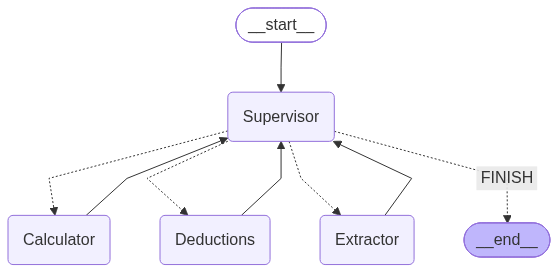

In [11]:
# Cell 3: (Optional) Visualize the LangGraph workflow structure in Colab
from IPython.display import Image, display

try:
    display(Image(tax_graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [12]:
# Cell 4: Execute query through orchestrator
user_input = (
    "I filed Single in 2025. W2 gross income was $115,000. "
    "I contributed $6,500 to a Traditional IRA, paid $2,500 in student loan interest, "
    "and made $1,000 in charitable contributions. What is my tax breakdown?"
)

inputs = {"messages": [HumanMessage(content=user_input)]}

print("--- Running Multi-Agent Execution ---\n")
for step in tax_graph.stream(inputs):
    for node_name, state_update in step.items():
        print(f"📌 Step: {node_name}")
        if "messages" in state_update:
            print(state_update["messages"][-1].content)
        elif "next_agent" in state_update:
            print(f"Routing Decision -> Next Target: {state_update['next_agent']}")
        print("=" * 60)

--- Running Multi-Agent Execution ---

📌 Step: Supervisor
Routing Decision -> Next Target: Extractor
📌 Step: Extractor
[Extractor Agent]: [{'type': 'text', 'text': 'Based on the information you provided, here is the extraction of your tax details, followed by an estimated tax breakdown for the 2025 tax year.\n\n### **Extracted Information**\n*   **Gross Income:** $115,000\n*   **Business Expenses:** $0 (None reported)\n*   **Retirement Contributions:** $6,500 (Traditional IRA)\n*   **Filing Status:** Single\n\n---\n\n### **Estimated 2025 Tax Breakdown**\n\n*Note: This calculation uses the IRS tax brackets and standard deduction limits released for the 2025 tax year. It assumes you are not covered by an employer-sponsored retirement plan (which allows you to fully deduct your IRA).*\n\n#### **1. Adjusted Gross Income (AGI) Calculation**\n*   **Gross Income:** $115,000\n*   **Traditional IRA Deduction:** -$6,500 \n*   **Student Loan Interest Deduction:** $0 *(Note: For 2025, the student 